In [2]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2607s 15us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


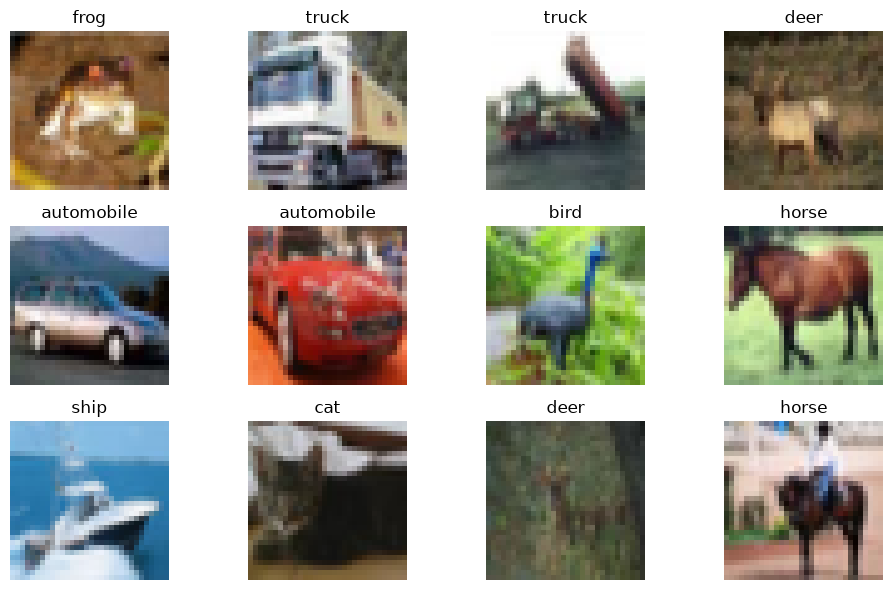

In [3]:
import matplotlib.pyplot as plt
class_names = [ "airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]
plt.figure(figsize=(10, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(10, activation="softmax")
])

model.summary()

c:\Users\PC-LAB1\Desktop\mu\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3553 - loss: 1.7342 - val_accuracy: 0.4964 - val_loss: 1.3643
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5051 - loss: 1.3742 - val_accuracy: 0.5640 - val_loss: 1.1844
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5699 - loss: 1.2158 - val_accuracy: 0.5880 - val_loss: 1.1291
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6113 - loss: 1.1076 - val_accuracy: 0.6446 - val_loss: 1.0146
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6379 - loss: 1.0307 - val_accuracy: 0.6680 - val_loss: 0.9633
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6618 - loss: 0.9725 - val_accuracy: 0.6842 - val_loss: 0.9076
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6818 - loss: 0.9106 - val_accuracy: 0.6974 - val_loss: 0.8735
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7004 - loss: 0.8644 - val_accuracy: 0.

In [10]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7203 - loss: 0.8381
Test accuracy: 0.720300018787384


In [11]:
predictions = model.predict(X_test)

y_pred = predictions.argmax(axis=1)
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


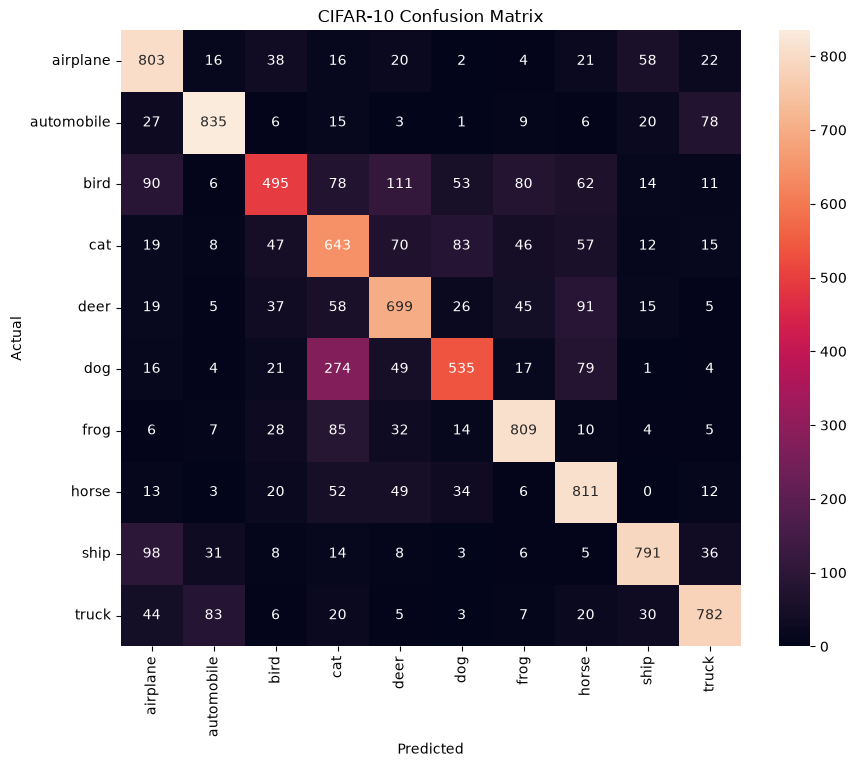

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CIFAR-10 Confusion Matrix")

plt.show()

In [15]:
wrong = []

for i in range(len(y_test)):
    if y_true[i] != y_pred[i]:
        wrong.append(i)

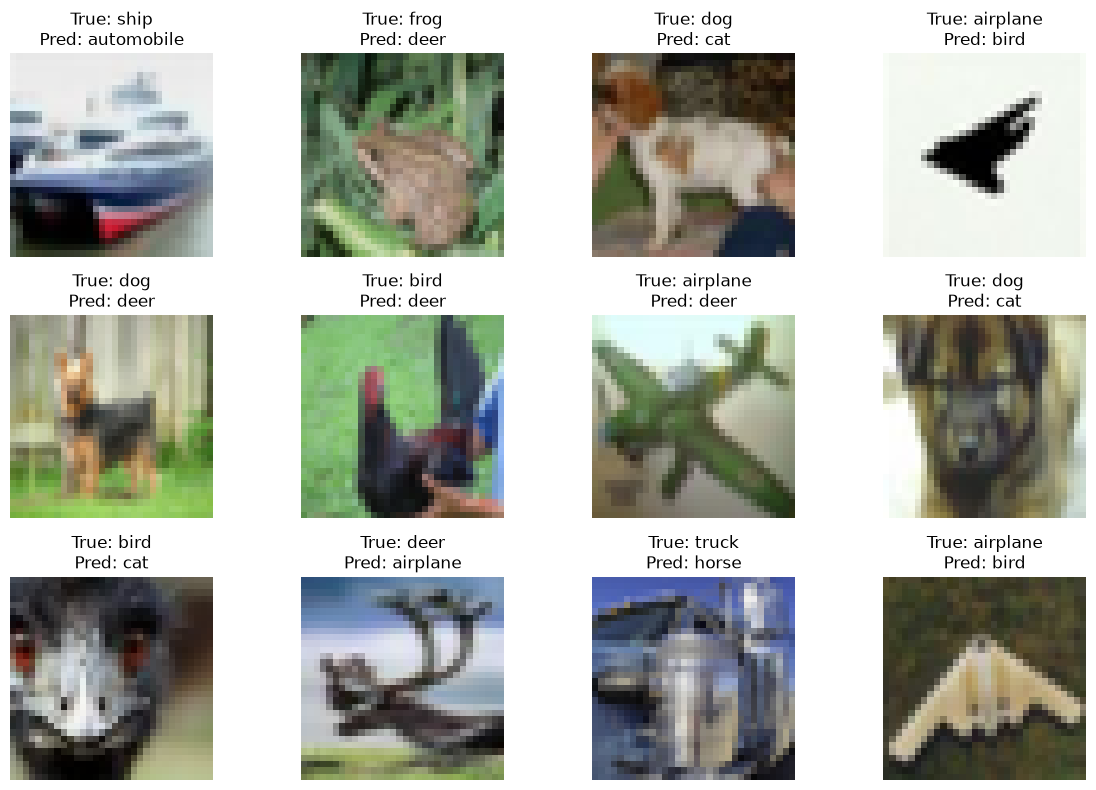

In [16]:
plt.figure(figsize=(12, 8))

for j, i in enumerate(wrong[:12]):

    plt.subplot(3, 4, j + 1)

    plt.imshow(X_test[i])

    plt.title(
        f"True: {class_names[y_true[i]]}\n"
        f"Pred: {class_names[y_pred[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomZoom

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

In [18]:
model = Sequential([

    data_augmentation,

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(10, activation="softmax")
])

In [ ]:
#########################

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling2D,
    Dropout
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [20]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (50000, 32, 32, 3)
y_train: (50000, 1)
X_test: (10000, 32, 32, 3)
y_test: (10000, 1)


In [21]:
y_train = y_train.flatten()
y_test = y_test.flatten()

print(y_train.shape)
print(y_test.shape)

(50000,)
(10000,)


In [22]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [24]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [25]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [26]:
inputs = Input(shape=(32, 32, 3))

x = data_augmentation(inputs)

x = tf.keras.layers.Resizing(96, 96)(x)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.5)(x)

outputs = Dense(10, activation="softmax")(x)

model = Model(inputs, outputs)

In [27]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

In [30]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 101ms/step - accuracy: 0.5729 - loss: 1.2341 - val_accuracy: 0.7946 - val_loss: 0.6046 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 100ms/step - accuracy: 0.6440 - loss: 1.0277 - val_accuracy: 0.8014 - val_loss: 0.5958 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 107s 152ms/step - accuracy: 0.6648 - loss: 0.9755 - val_accuracy: 0.8186 - val_loss: 0.5326 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 150s 213ms/step - accuracy: 0.6734 - loss: 0.9540 - val_accuracy: 0.8150 - val_loss: 0.5351 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 159ms/step - accuracy: 0.6796 - loss: 0.9351 - val_accuracy: 0.8346 - val_loss: 0.5005 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 123s 175ms/step - accuracy: 0.6876 - loss: 0.9087 - val_accuracy: 0.8312 - val_loss: 0.5082 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 104ms/step - accuracy:

In [31]:
model.save(
    "mobilenetv2_cifar10_final.keras"
)

In [33]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.8310 - loss: 0.4832
Test Loss: 0.48319247364997864
Test Accuracy: 0.8309999704360962


In [34]:
import tensorflow as tf
import os

model = tf.keras.models.load_model("mobilenetv2_cifar10_final.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [35]:
base_model = None

for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

print("Base model:", base_model.name)

Base model: sequential_3


In [36]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Fine-tuning آخر 30 طبقة")

Fine-tuning آخر 30 طبقة


In [37]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
checkpoint_path = "mobilenetv2_cifar10_finetuned.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [39]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [40]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[
        checkpoint,
        early_stopping
    ]
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7233 - loss: 0.7961
Epoch 1: val_accuracy improved from None to 0.84700, saving model to mobilenetv2_cifar10_finetuned.keras

Epoch 1: finished saving model to mobilenetv2_cifar10_finetuned.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 151ms/step - accuracy: 0.7233 - loss: 0.7961 - val_accuracy: 0.8470 - val_loss: 0.4732
Epoch 2/10
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7253 - loss: 0.7987
Epoch 2: val_accuracy improved from 0.84700 to 0.84860, saving model to mobilenetv2_cifar10_finetuned.keras

Epoch 2: finished saving model to mobilenetv2_cifar10_finetuned.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 108s 103ms/step - accuracy: 0.7253 - loss: 0.7987 - val_accuracy: 0.8486 - val_loss: 0.4716
Epoch 3/10
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7284 - loss: 0.7946
Epoch 3: val_accuracy did not improve from 0.84860
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 102ms/step - accuracy: 0.7283 - loss: 0.7947 - val_accura

In [41]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.8319 - loss: 0.4812
Test Loss: 0.48120468854904175
Test Accuracy: 0.8319000005722046


In [43]:
model.save("mobilenetv2_cifar10_finetuned_final.keras")

print("Final model saved successfully!")

Final model saved successfully!


In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[803  16  38  16  20   2   4  21  58  22]
 [ 27 835   6  15   3   1   9   6  20  78]
 [ 90   6 495  78 111  53  80  62  14  11]
 [ 19   8  47 643  70  83  46  57  12  15]
 [ 19   5  37  58 699  26  45  91  15   5]
 [ 16   4  21 274  49 535  17  79   1   4]
 [  6   7  28  85  32  14 809  10   4   5]
 [ 13   3  20  52  49  34   6 811   0  12]
 [ 98  31   8  14   8   3   6   5 791  36]
 [ 44  83   6  20   5   3   7  20  30 782]]


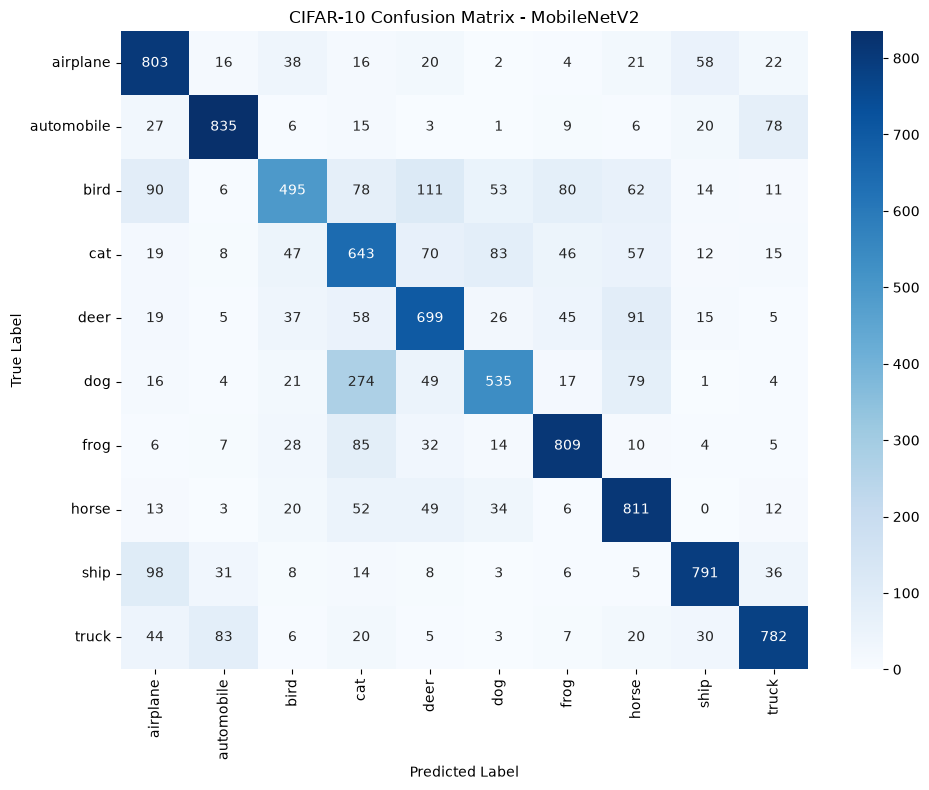

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CIFAR-10 Confusion Matrix - MobileNetV2")

plt.tight_layout()
plt.show()